# OpenCV와 얼굴 검출

In [1]:
# YuNet 얼굴 검출기 모델 사용
# OpenCV 공식 objetect모듈에 내장된 cv2.FaceDetectYN 사용. (ONNX 모델)

# 영상내의 얼굴 검출 뿐만 아니라, 랜드마크(눈, 코, 입) 좌표까지 함께 제공

# import

In [2]:
import sys, os
import numpy as np
import cv2
import matplotlib.pyplot as plt

print('OpenCV version:', cv2.__version__)  # 5.x 인지 확인

def cv2_imshow(image):
    cv2.imshow('image', image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()
    for _ in range(5):
        cv2.waitKey(1)

def plt_imshow(image, axis=True):  # OpenCV 이미지를 matplotlib 으로 출력하기
    img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis(axis)
    plt.show()


OpenCV version: 5.0.0


In [19]:
base_path = r"/Users/leo/LeoData/MyCode/KoreaITAcademy/LangChain/dataset/ComputerVision/dnnface"

# YuNet 모델 다운로드

- OpenCV Zoo 의 사전학습 얼굴검출 모델입니다.
- OpenCV 5 로 넘어오면서 모델 저장소가 GitHub 에서 **Hugging Face**
  (`https://huggingface.co/opencv`) 로 이전되었습니다.
- 사용할 모델: `face_detection_yunet_2023mar.onnx` (약 230KB)


In [20]:
import urllib.request

model_path = os.path.join(base_path, 'face_detection_yunet_2023mar.onnx')

if not os.path.exists(model_path):
    url = 'https://huggingface.co/opencv/face_detection_yunet/resolve/main/face_detection_yunet_2023mar.onnx'
    print('다운로드 중...', url)
    urllib.request.urlretrieve(url, model_path)
    print('다운로드 완료:', model_path)
else:
    print('이미 존재함:', model_path)


이미 존재함: /Users/leo/LeoData/MyCode/KoreaITAcademy/LangChain/dataset/ComputerVision/dnnface/face_detection_yunet_2023mar.onnx


# 영상 한장 준비
- 카메라

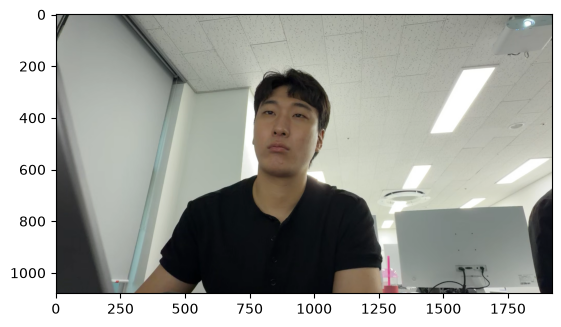

In [12]:
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print('💥 Camera open failed!')
    exit()
else:
    _, frame = cap.read()

    if frame is None:
        print('💥 읽어오기 실패')
    else:
        plt_imshow(frame)

cap.release()

# 얼굴 검출기 생성 (FaceDetectorYN)

기존 `cv2.dnn.readNet(model, config)` + `net.forward()` 방식 대신,
OpenCV 5 에서도 그대로 쓸 수 있는 **`cv2.FaceDetectorYN`** 고수준 API 를 사용합니다.

내부적으로 `blobFromImage`, `forward()` 를 알아서 처리해주기 때문에
원본 Caffe 예제보다 코드가 더 간결해집니다.


In [13]:
# 입력프레임의 크기
h, w = frame.shape[:2]
print(h, w)

1080 1920


In [14]:
face_detector = cv2.FaceDetectorYN.create(
    model_path,    # ONNX 모델 경로
    "",            # config (현재 onnx 모델에는 필요 없슴, 빈문자열)
    (w, h),        # 입력크기 (가로, 세로) - 원본 프레임 크기 그대로 사용 가능!
    score_threshold=0.6,   # confidence threshold  (YuNet 권장값)
    nms_threshold=0.3,  # 비최대억제 (Non-Maximum Suppression) 임계값.
    top_k=500,   # NMS 수행하기전 , 점수가 높은 순서대로 최대 몇개의 후보 바운딩박스를 유지할기 결정하는 한도
)

[ WARN:0@71.188] global net_impl_backend.cpp:345 setPreferableTarget Targets are not supported by the new graph engine for now


In [15]:
# 추론, 예측하기
_, faces = face_detector.detect(frame)

print(faces.shape)

# faces: N x 15
# [x, y, w, h,  우안x,y, 좌안x,y, 코x,y, 우측입꼬리x,y, 좌측입꼬리x,y,  confidence]

(1, 15)


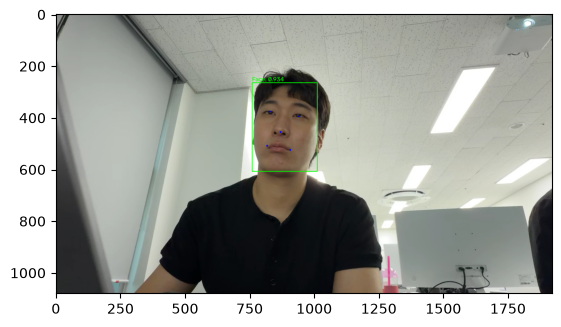

In [16]:
# 검출된 얼굴마다 사각형 + confidence + 랜드마크(눈/코/입) 그리기
# YuNet 은 내부적으로 NMS(top_k, nms_threshold) 까지 이미 처리해서 반환

if faces is not None:
    for face in faces:
        x1, y1, bw, bh = face[0:4].astype(int)  # 얼굴 위치
        confidence = face[-1]

        cv2.rectangle(frame, (x1, y1), (x1 + bw, y1 + bh), (0, 255, 0), 2)

        label = 'Face: %4.3f' % confidence
        cv2.putText(frame, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 1, cv2.LINE_AA)

        # 눈/코/입 랜드마크도 함께 표시
        landmarks = face[4:14].astype(int).reshape(5,2)
        for (lx, ly) in landmarks:
            cv2.circle(frame, (lx, ly), 2, (255, 0, 0), 2)
        
plt_imshow(frame)

In [18]:
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print('Camera open failed!')
    exit()

_, frame = cap.read()
h, w = frame.shape[:2]

face_detector = cv2.FaceDetectorYN.create(model_path, "", (w, h), 0.6, 0.3, 5000)

# if face_detector.empty():
#     print('FaceDetectorYN open failed!')
#     exit()

while True:  # 무한루프 돌면서 가져오기
    _, frame = cap.read()
    if frame is None:
        break

    _, faces = face_detector.detect(frame)

    if faces is not None:
        for face in faces:
            x1, y1, bw, bh = face[0:4].astype(int)
            confidence = face[-1]

            cv2.rectangle(frame, (x1, y1), (x1 + bw, y1 + bh), (0, 255, 0), 2)
            label = 'Face: %4.3f' % confidence
            cv2.putText(frame, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 1, cv2.LINE_AA)

    cv2.imshow('frame', frame)

    if cv2.waitKey(1) == 27:  # ESC 눌려야 빠져 나옴
        break

cap.release()
cv2.destroyAllWindows()
for _ in range(5):
    cv2.waitKey(1)


[ WARN:0@84.957] global net_impl_backend.cpp:345 setPreferableTarget Targets are not supported by the new graph engine for now
